# Unidade VI — Análise de Grupos

## Modelos de mistura Gaussiana (GMM)

**Carga estimada:** 2 horas  
**Pré-requisitos:** probabilidade básica, distribuição normal, k-means e avaliação de agrupamentos.

> **Pergunta norteadora:** e se os grupos forem distribuições sobrepostas e quisermos expressar incerteza sobre o pertencimento de cada objeto?

O GMM (*Gaussian Mixture Model*) representa os dados como uma mistura de distribuições Gaussianas. Seus componentes são modelos probabilísticos latentes; transformá-los em grupos substantivos exige validação.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- explicar componentes, pesos, médias e covariâncias de uma mistura;
- interpretar probabilidades posteriores, chamadas responsabilidades;
- descrever intuitivamente as etapas E e M do algoritmo EM;
- comparar atribuição rígida do k-means e atribuição probabilística do GMM;
- interpretar covariâncias esférica, diagonal, compartilhada e completa;
- usar AIC e BIC como evidências, reconhecendo suas limitações.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. Uma mistura como processo gerador

O modelo supõe que cada objeto foi gerado em duas etapas: escolher um componente $j$ com probabilidade $\pi_j$ e, depois, sortear o objeto da Gaussiana desse componente. Para $k$ componentes:

$$p(\mathbf{x})=\sum_{j=1}^{k}\pi_j\,\mathcal{N}(\mathbf{x}\mid\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j),\qquad \sum_j\pi_j=1.$$

- $\pi_j$: peso ou proporção esperada do componente;
- $\boldsymbol{\mu}_j$: centro da distribuição;
- $\boldsymbol{\Sigma}_j$: variâncias e covariâncias, que definem dispersão, orientação e forma.

Diferentemente do k-means, o GMM não afirma inicialmente que cada objeto pertence exclusivamente a um grupo. Ele estima quanto cada componente é responsável por explicar o objeto.

,componente,peso,média,desvio
0,0,0.619,-0.018,0.562
1,1,0.381,2.157,0.984


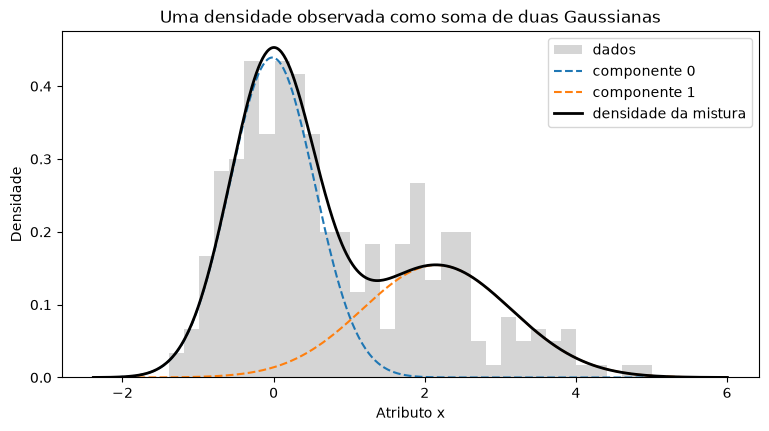

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
x_1d = np.concatenate([rng.normal(0.0, 0.65, 180), rng.normal(2.1, 1.0, 120)])[:, None]
gmm_1d = GaussianMixture(n_components=2, n_init=20, random_state=RANDOM_STATE).fit(x_1d)
ordem = np.argsort(gmm_1d.means_.ravel())
parametros = pd.DataFrame({
    "componente": [0, 1],
    "peso": gmm_1d.weights_[ordem],
    "média": gmm_1d.means_.ravel()[ordem],
    "desvio": np.sqrt(gmm_1d.covariances_.ravel()[ordem]),
})
display(parametros.round(3))

grade = np.linspace(x_1d.min() - 1, x_1d.max() + 1, 600)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(x_1d.ravel(), bins=32, density=True, alpha=0.30, color="#777777", label="dados")
mistura = np.zeros_like(grade)
for linha in parametros.itertuples():
    componente = linha.peso * norm.pdf(grade, linha.média, linha.desvio)
    mistura += componente
    ax.plot(grade, componente, linestyle="--", label=f"componente {linha.componente}")
ax.plot(grade, mistura, color="black", linewidth=2, label="densidade da mistura")
ax.set(title="Uma densidade observada como soma de duas Gaussianas", xlabel="Atributo x", ylabel="Densidade")
ax.legend()
plt.show()

## 2. Responsabilidade: pertencimento com incerteza

A responsabilidade do componente $j$ pelo objeto $i$ é a probabilidade posterior:

$$r_{ij}=P(z_i=j\mid\mathbf{x}_i)=\frac{\pi_j\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)}{\sum_{l=1}^{k}\pi_l\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_l,\boldsymbol{\Sigma}_l)}.$$

Para cada objeto, as responsabilidades somam 1. Uma atribuição rígida pode escolher o maior valor, mas manter o vetor completo revela fronteiras e casos ambíguos. Probabilidade posterior é condicional às hipóteses do modelo; 0,80 não significa uma verdade universal de 80%.

## 3. EM: alternar expectativa e maximização

Como o componente que gerou cada objeto é latente, o algoritmo de Expectation–Maximization alterna:

1. **Etapa E:** calcular responsabilidades usando os parâmetros atuais;
2. **Etapa M:** atualizar pesos, médias e covariâncias usando essas responsabilidades como pesos;
3. repetir até que o ganho de log-verossimilhança seja pequeno.

A log-verossimilhança não diminui durante as iterações, mas o algoritmo pode convergir para um ótimo local. Por isso usamos várias inicializações (`n_init`) e fixamos a semente para reprodução. Componentes também podem trocar de número entre execuções sem que o modelo mude.

## 4. A covariância define a geometria

No scikit-learn, `covariance_type` controla a flexibilidade:

| Tipo | Hipótese geométrica | Complexidade relativa |
|---|---|---|
| `spherical` | cada componente é circular/esférico | menor |
| `diag` | elipse alinhada aos eixos | baixa |
| `tied` | todos compartilham uma covariância completa | intermediária |
| `full` | cada componente tem sua própria covariância completa | maior |

Mais flexibilidade melhora o ajuste aparente, mas aumenta parâmetros e risco de sobreajuste. Padronização continua importante quando unidades diferentes não devem definir dispersões.

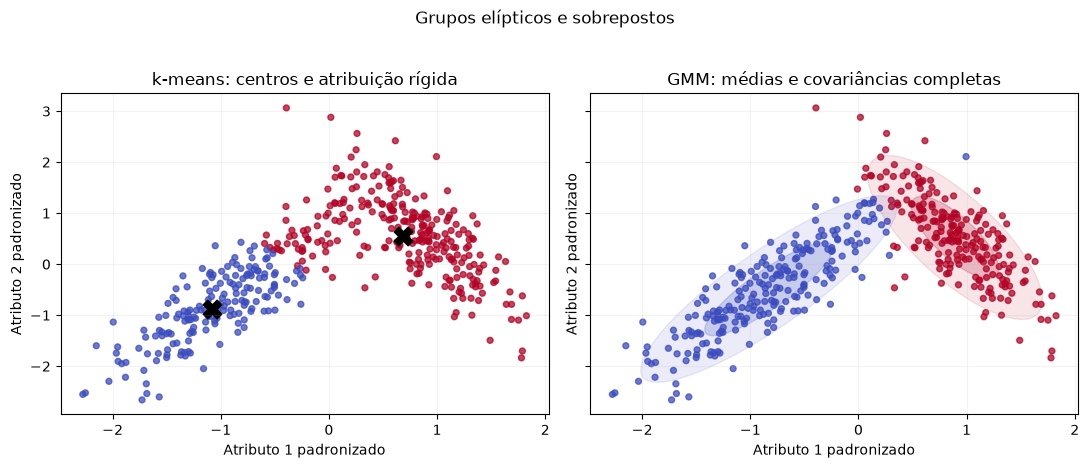

In [3]:
X_a = rng.multivariate_normal([-2.0, 0.0], [[2.0, 1.25], [1.25, 1.0]], size=240)
X_b = rng.multivariate_normal([2.0, 1.0], [[1.1, -0.65], [-0.65, 0.65]], size=210)
X = StandardScaler().fit_transform(np.vstack([X_a, X_b]))
kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit(X)
gmm = GaussianMixture(n_components=2, covariance_type="full", n_init=20, random_state=RANDOM_STATE).fit(X)
labels_gmm = gmm.predict(X)

def adicionar_elipse(ax, media, cov, cor):
    valores, vetores = np.linalg.eigh(cov)
    ordem = valores.argsort()[::-1]
    valores, vetores = valores[ordem], vetores[:, ordem]
    angulo = np.degrees(np.arctan2(vetores[1, 0], vetores[0, 0]))
    for escala, alpha in [(2, 0.20), (4, 0.10)]:
        ax.add_patch(Ellipse(media, *(escala * np.sqrt(valores)), angle=angulo, facecolor=cor, edgecolor=cor, alpha=alpha))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="coolwarm", s=18, alpha=0.75)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=180, color="black")
axes[0].set_title("k-means: centros e atribuição rígida")
cores = ["#3b4cc0", "#b40426"]
axes[1].scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap="coolwarm", s=18, alpha=0.75)
for j in range(2): adicionar_elipse(axes[1], gmm.means_[j], gmm.covariances_[j], cores[j])
axes[1].set_title("GMM: médias e covariâncias completas")
for ax in axes: ax.set(xlabel="Atributo 1 padronizado", ylabel="Atributo 2 padronizado"); ax.grid(alpha=0.15)
fig.suptitle("Grupos elípticos e sobrepostos", y=1.03)
fig.tight_layout()
plt.show()

,objeto,P(componente 0),P(componente 1),maior responsabilidade
0,154,0.502,0.498,0.502
1,120,0.506,0.494,0.506
2,24,0.470,0.530,0.530
3,180,0.538,0.462,0.538
4,449,0.572,0.428,0.572
5,81,0.419,0.581,0.581
6,55,0.620,0.380,0.620
7,41,0.621,0.379,0.621
8,183,0.643,0.357,0.643
9,324,0.348,0.652,0.652


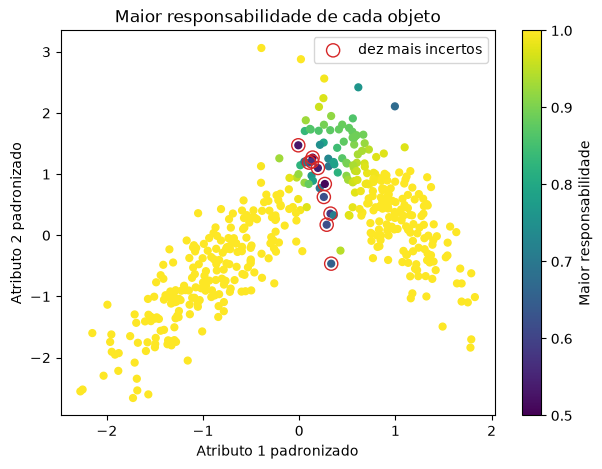

In [4]:
responsabilidades = gmm.predict_proba(X)
confianca = responsabilidades.max(axis=1)
incertos = np.argsort(confianca)[:10]
display(pd.DataFrame({
    "objeto": incertos,
    "P(componente 0)": responsabilidades[incertos, 0],
    "P(componente 1)": responsabilidades[incertos, 1],
    "maior responsabilidade": confianca[incertos],
}).round(3))

fig, ax = plt.subplots(figsize=(7, 5))
pontos = ax.scatter(X[:, 0], X[:, 1], c=confianca, cmap="viridis", vmin=0.5, vmax=1.0, s=24)
ax.scatter(X[incertos, 0], X[incertos, 1], facecolors="none", edgecolors="#d62728", s=90, label="dez mais incertos")
ax.set(title="Maior responsabilidade de cada objeto", xlabel="Atributo 1 padronizado", ylabel="Atributo 2 padronizado")
fig.colorbar(pontos, ax=ax, label="Maior responsabilidade")
ax.legend()
plt.show()

## 5. Quantos componentes? AIC e BIC

Aumentar componentes eleva a verossimilhança, mas também a complexidade. AIC e BIC equilibram ajuste e número de parâmetros; **menor é melhor**. O BIC penaliza complexidade mais fortemente conforme cresce a amostra.

Eles selecionam entre modelos candidatos sob hipóteses Gaussianas. Não demonstram que componentes sejam categorias naturais, nem substituem estabilidade, interpretação, diagnóstico de ajuste e finalidade.

,componentes,AIC,BIC
0,1,2395.7,2416.2
1,2,1843.1,1888.3
2,3,1849.9,1919.7
3,4,1864.0,1958.5
4,5,1874.5,1993.7
5,6,1877.6,2021.4


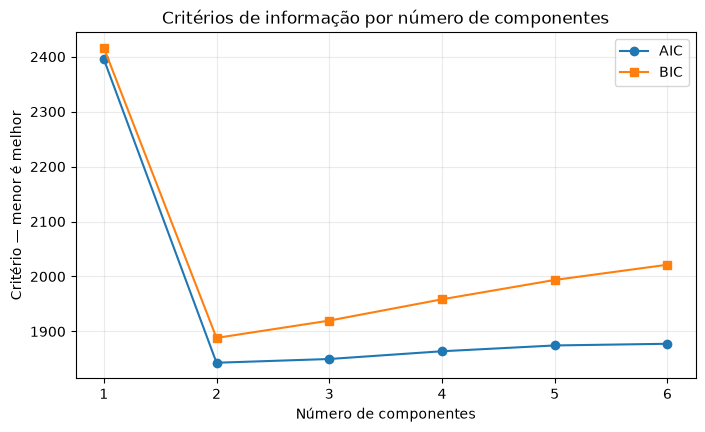

In [5]:
criterios = []
for k in range(1, 7):
    modelo = GaussianMixture(n_components=k, covariance_type="full", n_init=10, random_state=RANDOM_STATE).fit(X)
    criterios.append({"componentes": k, "AIC": modelo.aic(X), "BIC": modelo.bic(X)})
criterios = pd.DataFrame(criterios)
display(criterios.round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(criterios["componentes"], criterios["AIC"], marker="o", label="AIC")
ax.plot(criterios["componentes"], criterios["BIC"], marker="s", label="BIC")
ax.set(title="Critérios de informação por número de componentes", xlabel="Número de componentes", ylabel="Critério — menor é melhor")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 6. Quando considerar GMM — e quando desconfiar

GMM é interessante quando grupos podem ser elípticos, sobrepostos e descritos aproximadamente por Gaussianas, e quando a incerteza de pertencimento importa.

Cuidados principais:

- componentes não Gaussianos ou formas curvas podem exigir outro método;
- muitos atributos tornam covariâncias completas difíceis de estimar;
- uma covariância pode colapsar sobre poucos pontos e produzir solução degenerada; `reg_covar` adiciona regularização;
- inicialização e ótimo local exigem múltiplas execuções;
- valores ausentes, escala e outliers precisam de tratamento consciente;
- componentes probabilísticos não são automaticamente grupos sociais ou causais.

| Método | Pertencimento | Geometria central | Diferencial |
|---|---|---|---|
| k-means | rígido | aproximadamente esférica | simplicidade e escala |
| GMM | probabilístico | elíptica sob Gaussianas | incerteza e covariância |
| DBSCAN | rígido + ruído | regiões densas conectadas | formas não convexas |
| k-medoids | rígido | definida pela dissimilaridade | representante observado |
| grade | célula/região | dependente da quantização | resumos e multirresolução |

## 7. Atividades

**U06-NB06-V01.** Um objeto possui responsabilidades `[0.52, 0.45, 0.03]`. Qual seria sua atribuição rígida? Por que comunicar apenas esse rótulo perde informação importante?

**U06-NB06-E01.** Em uma mistura, $\pi_1=0{,}6$, $p(x\mid C_1)=0{,}2$, $\pi_2=0{,}4$ e $p(x\mid C_2)=0{,}5$. Calcule $P(C_1\mid x)$ e $P(C_2\mid x)$ pela normalização das contribuições.

**U06-NB06-E02.** Explique as etapas E e M usando pesos, médias e covariâncias. Por que múltiplas inicializações continuam necessárias?

**U06-NB06-E03.** Compare `spherical`, `diag`, `tied` e `full`. Para dois grupos elípticos com orientações diferentes, qual é a escolha inicial mais flexível e qual é seu custo?

**U06-NB06-E04.** Uma tabela apresenta BICs 1250, 980, 910, 925 e 947 para um a cinco componentes. Qual modelo o BIC prefere? Indique três verificações necessárias antes de tratá-lo como solução final.

**U06-NB06-E05.** Compare GMM, k-means e DBSCAN para dados com dois grupos elípticos sobrepostos e alguns pontos isolados. Proponha uma análise que preserve a incerteza e trate os isolados sem conclusões automáticas.

## 8. Síntese

- GMM representa dados como uma soma ponderada de distribuições Gaussianas.
- Responsabilidades expressam pertencimento probabilístico condicional ao modelo.
- EM alterna cálculo das responsabilidades e atualização dos parâmetros.
- Covariâncias permitem componentes elípticos com dispersões e orientações diferentes.
- AIC e BIC equilibram ajuste e complexidade, mas não validam significado substantivo.
- Incerteza, ajuste, estabilidade e consequências devem ser comunicados junto aos rótulos.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seções 9.1.2 e 9.1.3.
- DEMPSTER, A. P.; LAIRD, N. M.; RUBIN, D. B. Maximum likelihood from incomplete data via the EM algorithm. *Journal of the Royal Statistical Society: Series B*, v. 39, n. 1, p. 1–38, 1977.
- SCIKIT-LEARN DEVELOPERS. `GaussianMixture`. Documentação oficial.

Os dados e as figuras deste notebook são autorais e gerados localmente.